# Exploring and Predicting Top streamed spotify songs using Lazy learners

### Library Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
from lazypredict.Supervised import LazyRegressor, LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [4]:
file_path = "spotify-2023.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")

### Preprocessing

In [6]:
df.reset_index(drop=True, inplace=True)

In [7]:
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    object 
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      903 non-null    object 
 14  bpm                   953 non-null    int64  
 15  key                   8

None

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.00,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.00,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.00,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.00,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.00,84,...,144,A,Minor,65,23,80,14,63,11,6


In [8]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  1
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64


In [9]:
df = df.dropna()

# EDA - Exploratory Data Analysis

In [13]:
most_streamed_song = df[df['streams'] == df['streams'].max()]
most_streamed_song

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
179,Shape of You,Ed Sheeran,1,2017,1,6,32181,10,3562543890.00,33,...,96,C#,Minor,83,93,65,58,0,9,8


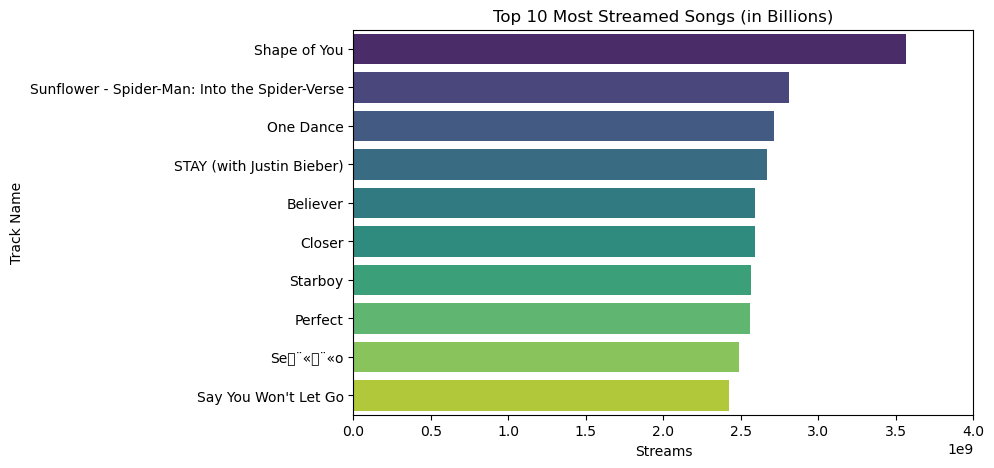

In [14]:
top_10_streamed_songs = df.sort_values(by='streams', ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(y=top_10_streamed_songs['track_name'], x=top_10_streamed_songs['streams'], palette='viridis')
plt.xlabel("Streams")
plt.ylabel("Track Name")
plt.title("Top 10 Most Streamed Songs (in Billions)")
plt.xlim(0,4000000000)
plt.gca()
plt.show()

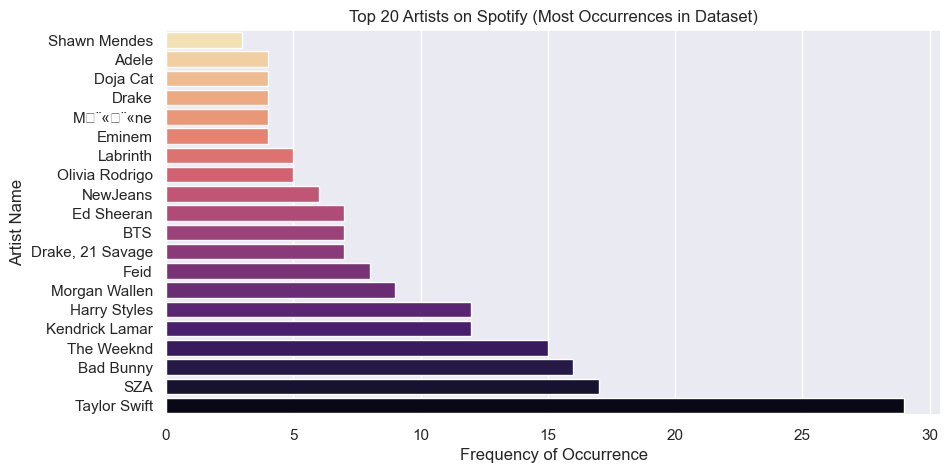

In [15]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="darkgrid") 
sns.barplot(
    y=df['artist(s)_name'].value_counts().head(20).index, 
    x=df['artist(s)_name'].value_counts().head(20).values, 
    palette='magma'
)
plt.xlabel("Frequency of Occurrence")
plt.ylabel("Artist Name")
plt.title("Top 20 Artists on Spotify (Most Occurrences in Dataset)")
plt.gca().invert_yaxis()
plt.show()

In [16]:
# Get the average energy of songs released by each artist
avg_energy_per_artist = df.groupby(['artist(s)_name', 'track_name'])['energy_%'].mean()
avg_energy_per_artist = avg_energy_per_artist.sort_values(ascending=False)
print(avg_energy_per_artist.head(10))

artist(s)_name                  track_name                           
Kordhell                        Murder In My Mind                       97.00
Bebe Rexha, David Guetta        I'm Good (Blue)                         97.00
PSY, Suga                       That That (prod. & feat. SUGA of BTS)   96.00
dennis, MC Kevin o Chris        T¨«¨                                  96.00
Israel & Rodolffo, Ana Castela  Bombonzinho - Ao Vivo                   95.00
Surf Curse                      Freaks                                  94.00
NewJeans                        Hype Boy                                94.00
YOASOBI                         ????????????                            94.00
Kenshi Yonezu                   KICK BACK                               94.00
Duki                            Antes de Perderte                       93.00
Name: energy_%, dtype: float64


In [17]:
# Get the top 10 most acoustic songs
top_10_acoustic_songs = df.sort_values('acousticness_%', ascending=False).head(10)
print(top_10_acoustic_songs[['track_name', 'artist(s)_name', 'acousticness_%']].to_string(index=False))

                                 track_name                                                     artist(s)_name  acousticness_%
                           The Night We Met                                                         Lord Huron              97
                              Miserable Man                                                      David Kushner              93
                       lovely - Bonus Track                                              Billie Eilish, Khalid              93
                                    Forever                                                           Labrinth              92
                                  All of Me                                                        John Legend              92
                                      Blind                                                                SZA              91
                            Kahani Suno 2.0                                                       Kaifi Khalil 

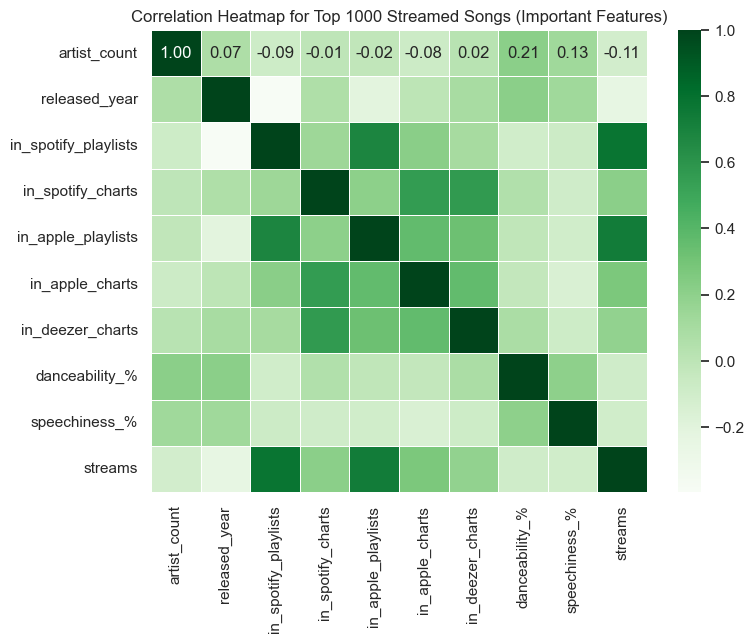

In [18]:
# Selecting the top 1000 streamed songs
top_1000_songs = df.sort_values(by='streams', ascending=False).head(1000)
numeric_features = ['artist_count', 'released_year',
                    'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
                    'in_apple_charts', 'in_deezer_charts', 'danceability_%' , 
                     'speechiness_%', 'streams']
corr_matrix = top_1000_songs[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.heatmap(corr_matrix, annot=True, cmap="Greens", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Top 1000 Streamed Songs (Important Features)")
plt.show()

In [19]:
# Group songs by key and count the occurrences of each key
key_counts = df['key'].value_counts()
key_counts = key_counts.sort_values(ascending=False)
top_5_keys = key_counts.head(5)
print(top_5_keys)

key
C#    115
G      91
F      87
G#     85
D      78
Name: count, dtype: int64


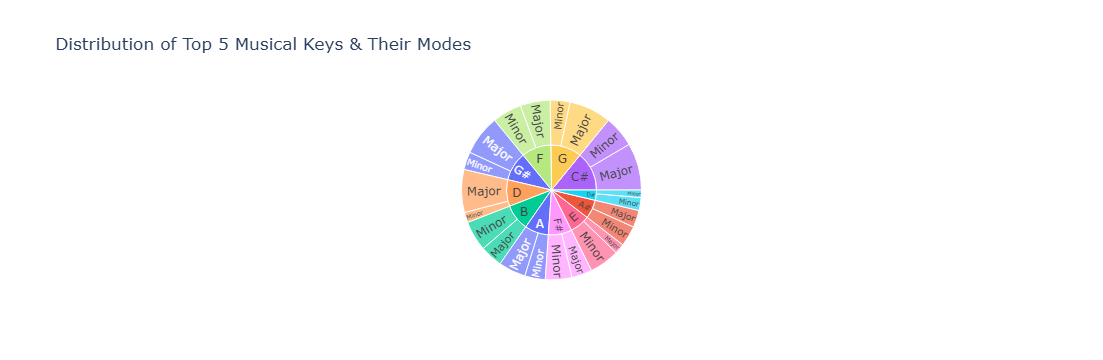

In [20]:
# Count occurrences of each key and mode
key_mode_counts = df.groupby(['key', 'mode']).size().reset_index(name='count')
top_5_keys = df['key'].value_counts().head(5).index
fig = px.sunburst(key_mode_counts, 
                  path=['key', 'mode'], 
                  values='count', 
                  color='key',
                  title="Distribution of Top 5 Musical Keys & Their Modes")

fig.show()

season_released
Spring    250
Winter    233
Autumn    175
Summer    158
Name: count, dtype: int64


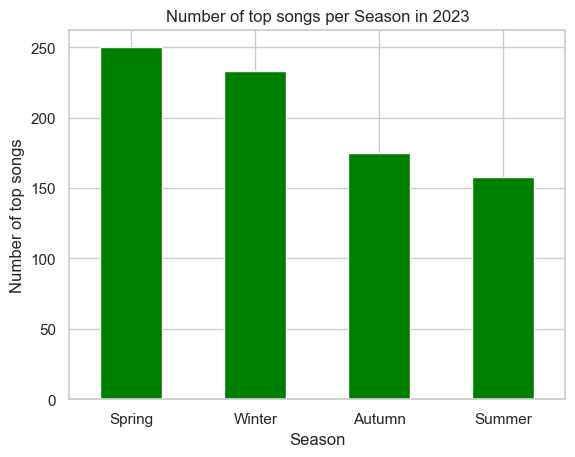

In [21]:
# Identify the most popular songs by season
df['season_released'] = df['released_month'].apply(lambda x: 'Spring' if x in [3, 4, 5] else
                                       'Summer' if x in [6, 7, 8] else
                                       'Autumn' if x in [9, 10, 11] else
                                       'Winter')
season_counts = df['season_released'].value_counts()
print(season_counts.head(10))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Season')
plt.ylabel('Number of top songs')
plt.title('Number of top songs per Season in 2023')
plt.xticks(rotation=0)  
plt.show()

In [22]:
# Top 10 streams on spotify
top_10_streamed_songs = df.sort_values(by='streams', ascending=False).head(10)
print(top_10_streamed_songs[['track_name', 'artist(s)_name', 'streams', 'released_year', 'season_released']].to_string(index=False))

                                   track_name               artist(s)_name       streams  released_year season_released
                                 Shape of You                   Ed Sheeran 3562543890.00           2017          Winter
Sunflower - Spider-Man: Into the Spider-Verse        Post Malone, Swae Lee 2808096550.00           2018          Autumn
                                    One Dance          Drake, WizKid, Kyla 2713922350.00           2016          Spring
                    STAY (with Justin Bieber) Justin Bieber, The Kid Laroi 2665343922.00           2021          Summer
                                     Believer              Imagine Dragons 2594040133.00           2017          Winter
                                       Closer     The Chainsmokers, Halsey 2591224264.00           2016          Spring
                                      Starboy        The Weeknd, Daft Punk 2565529693.00           2016          Autumn
                                      Pe

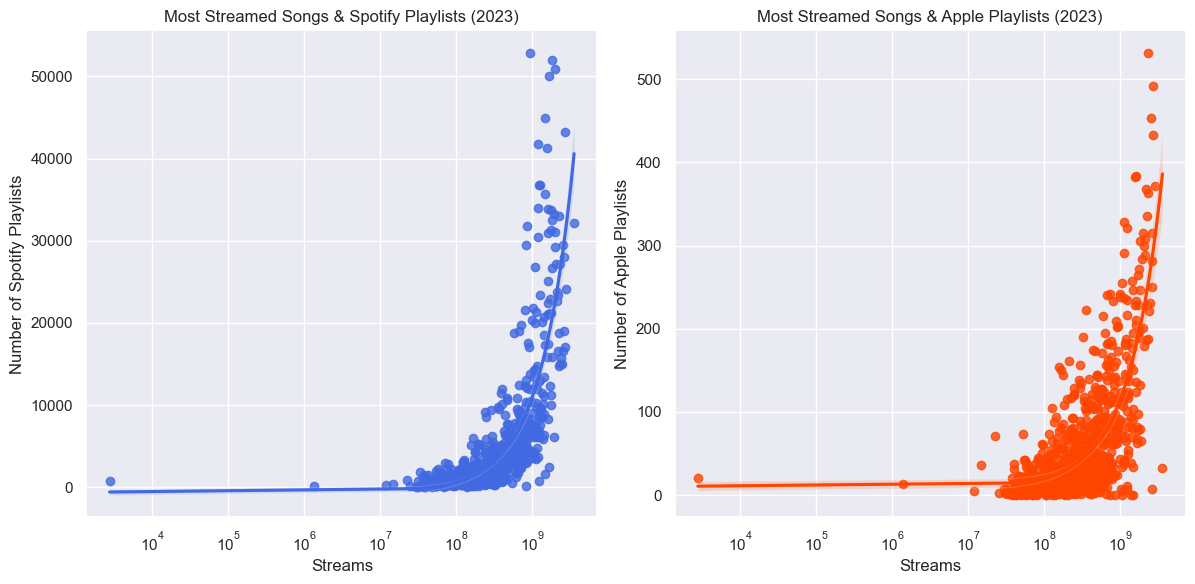

In [23]:
plt.figure(figsize=(18, 6))
sns.set_theme(style="darkgrid")
colors = ["royalblue", "orangered"]
plt.subplot(1, 3, 1)
sns.regplot(
    x=df['streams'], 
    y=df['in_spotify_playlists'], 
    scatter=True, 
    fit_reg=True, 
    color=colors[0]
)
plt.title("Most Streamed Songs & Spotify Playlists (2023)")
plt.xlabel("Streams")
plt.ylabel("Number of Spotify Playlists")
plt.xscale("log")

plt.subplot(1, 3, 2)
sns.regplot(
    x=df['streams'], 
    y=df['in_apple_playlists'], 
    scatter=True, 
    fit_reg=True, 
    color=colors[1]
)
plt.title("Most Streamed Songs & Apple Playlists (2023)")
plt.xlabel("Streams")
plt.ylabel("Number of Apple Playlists")
plt.xscale("log")
plt.tight_layout()
plt.show()

# Model Evaluation Using Regression

In [27]:
df = df.dropna()

In [28]:
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('streams') 
X = df[numeric_features]
y = df['streams']

In [29]:
X.columns

Index(['artist_count', 'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
       'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%',
       'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%',
       'liveness_%', 'speechiness_%'],
      dtype='object')

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
print(X_train.shape, X_test.shape)
print("NaN values in X_train:", np.isnan(X_train).sum().sum())
print("NaN values in X_test:", np.isnan(X_test).sum().sum())
print("Infinite values in X_train:", np.isinf(X_train).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test).sum().sum())

(652, 17) (164, 17)
NaN values in X_train: 0
NaN values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0


In [33]:
print("NaN values in y_train:", np.isnan(y_train).sum())
print("NaN values in y_test:", np.isnan(y_test).sum())

NaN values in y_train: 0
NaN values in y_test: 0


In [34]:
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

In [35]:
print("Dataset Columns:", df.columns)
print("Selected Features:", numeric_features)

Dataset Columns: Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%',
       'season_released'],
      dtype='object')
Selected Features: ['artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']


### Regression Models with their R-Square values

In [37]:
# Linear Regressor
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr_score = r2_score(y_test, y_pred_lr)

print("Linear Regression R-Squared:", lr_score)

Linear Regression R-Squared: 0.7515748188036413


In [38]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_score = r2_score(y_test, y_pred_rf)
print("Random Forest R-Squared:", rf_score)

Random Forest R-Squared: 0.8610131813024564


In [39]:
# Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
gb_score = r2_score(y_test, y_pred_gb)
print("Gradient Boosting R-Squared: ", gb_score)

Gradient Boosting R-Squared:  0.8662089912738622


In [40]:
# LGBM Regressor
lgbm = LGBMRegressor(n_estimators=100, learning_rate=0.09, random_state=42)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
lgbm_score = r2_score(y_test, y_pred_lgbm)
print("LGBM Regressor R-Squared: ",lgbm_score)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1077
[LightGBM] [Info] Number of data points in the train set: 652, number of used features: 17
[LightGBM] [Info] Start training from score 458769196.831288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [41]:
# XGB Regressor
xgb = XGBRegressor(n_estimators=100, learning_rate=0.10, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
xgb_score = r2_score(y_test, y_pred_xgb)
print("XGB Regressor R-Squared: ",xgb_score)

XGB Regressor R-Squared:  0.8350754727287176


In [42]:
# Support Vector Regressor
svr = SVR()
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
svr_score = r2_score(y_test, y_pred_svr)
print("Support Vector Regression R-Squared: ",svr_score)

Support Vector Regression R-Squared:  -0.20308209791440368


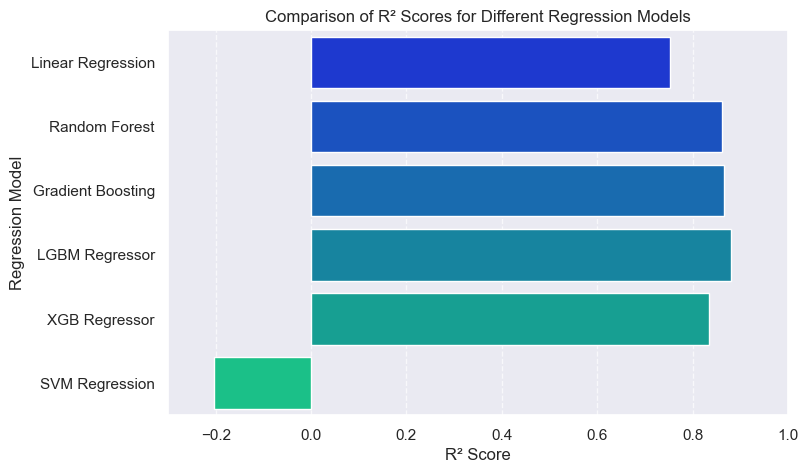

In [43]:

r2_scores = {
    "Linear Regression": lr_score,
    "Random Forest": rf_score,
    "Gradient Boosting": gb_score,
    "LGBM Regressor": lgbm_score,
    "XGB Regressor": xgb_score,
    "SVM Regression": svr_score
}

models = list(r2_scores.keys())
scores = list(r2_scores.values())
plt.figure(figsize=(8, 5))
sns.barplot(x=scores, y=models, palette="winter")  # Horizontal bars
plt.xlabel("R² Score")
plt.ylabel("Regression Model")
plt.title("Comparison of R² Scores for Different Regression Models")
plt.xlim(-0.3, 1) 
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


In [44]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

100%|██████████████████████████████████████████████████████████████████████████████████| 42/42 [00:06<00:00,  6.66it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 652, number of used features: 17
[LightGBM] [Info] Start training from score 458769196.831288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [45]:
models.head() # Print first few rows to check if it has data

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.86,0.87,197103183.56,0.10
HistGradientBoostingRegressor,0.85,0.87,203453842.16,0.42
GradientBoostingRegressor,0.84,0.86,206488171.75,0.43
RandomForestRegressor,0.84,0.86,207051298.66,1.13
BaggingRegressor,0.84,0.85,212661622.92,0.17


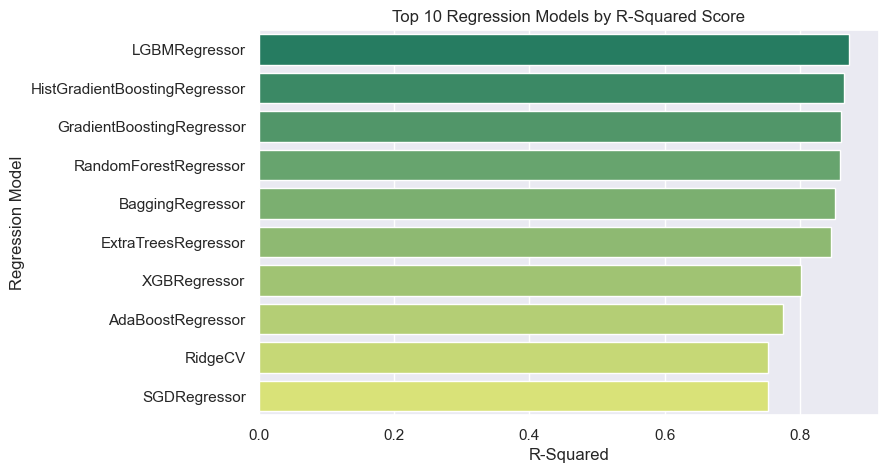

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(y=models.index[:10], x=models['R-Squared'][:10], palette='summer')
plt.xlabel("R-Squared")
plt.ylabel("Regression Model")
plt.title("Top 10 Regression Models by R-Squared Score")
plt.show()

#  Model Evaluation Using Classifiers

In [50]:
median_streams = df['streams'].median()
df['hit_song'] = (df['streams'] >= median_streams).astype(int)

In [51]:
numeric_features = ['artist_count', 'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
       'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%',
       'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%',
       'liveness_%', 'speechiness_%']
X = df[numeric_features]
y = df['hit_song']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Classification Models

In [55]:
# Decision tree Classifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_pred_dt_clf = dt_clf.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt_clf)
print(f"Random Forest Classifier Accuracy: {dt_accuracy}")
print(classification_report(y_test, y_pred_dt_clf))

Random Forest Classifier Accuracy: 0.8597560975609756
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        78
           1       0.87      0.86      0.87        86

    accuracy                           0.86       164
   macro avg       0.86      0.86      0.86       164
weighted avg       0.86      0.86      0.86       164



In [56]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf_clf = rf_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf_clf)
print(f"Random Forest Classifier Accuracy: {rf_accuracy}")
print(classification_report(y_test, y_pred_rf_clf))

Random Forest Classifier Accuracy: 0.8780487804878049
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        78
           1       0.90      0.86      0.88        86

    accuracy                           0.88       164
   macro avg       0.88      0.88      0.88       164
weighted avg       0.88      0.88      0.88       164



In [57]:
# gradient boost classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb_clf = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb_clf)
print(f"Gradient Boosting Classifier Accuracy: {gb_accuracy}")
print(classification_report(y_test, y_pred_gb_clf))

Gradient Boosting Classifier Accuracy: 0.8841463414634146
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        78
           1       0.91      0.86      0.89        86

    accuracy                           0.88       164
   macro avg       0.88      0.89      0.88       164
weighted avg       0.89      0.88      0.88       164



In [58]:
# Support vector machine classifier
svc = SVC()
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
svc_accuracy = accuracy_score(y_test, y_pred_svc)
print(f"Support Vector Classifier Accuracy: {svc_accuracy}")
print(classification_report(y_test, y_pred_svc))

Support Vector Classifier Accuracy: 0.8292682926829268
              precision    recall  f1-score   support

           0       0.76      0.95      0.84        78
           1       0.94      0.72      0.82        86

    accuracy                           0.83       164
   macro avg       0.85      0.83      0.83       164
weighted avg       0.85      0.83      0.83       164



In [59]:
# LG boost classifier
lgbm_clf = LGBMClassifier(n_estimators=100, learning_rate=0.09, random_state=42)
lgbm_clf.fit(X_train, y_train)
y_pred_lgbm_clf = lgbm_clf.predict(X_test)
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm_clf)
print(f"LGBM Classifier Accuracy: {lgbm_accuracy}")
print(classification_report(y_test, y_pred_lgbm_clf))

[LightGBM] [Info] Number of positive: 322, number of negative: 330
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1077
[LightGBM] [Info] Number of data points in the train set: 652, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493865 -> initscore=-0.024541
[LightGBM] [Info] Start training from score -0.024541
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [60]:
# XG Boost Classifier
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train, y_train)
y_pred_xgb_clf = xgb_clf.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb_clf)
print(f"XGB Classifier Accuracy: {xgb_accuracy}")
print(classification_report(y_test, y_pred_xgb_clf))

XGB Classifier Accuracy: 0.8780487804878049
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        78
           1       0.90      0.86      0.88        86

    accuracy                           0.88       164
   macro avg       0.88      0.88      0.88       164
weighted avg       0.88      0.88      0.88       164



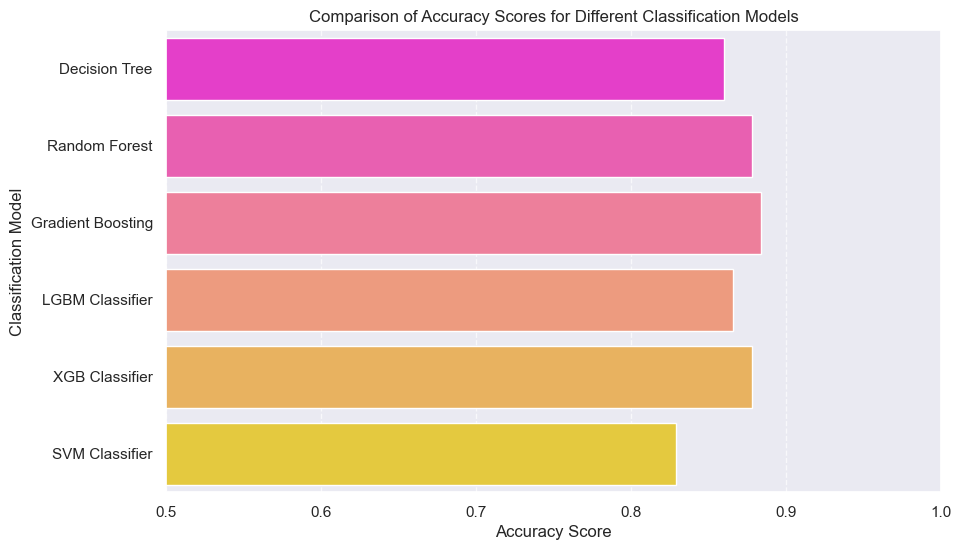

In [61]:
# Dictionary of models and their corresponding accuracy scores
accuracy_scores = {
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "Gradient Boosting": gb_accuracy,
    "LGBM Classifier": lgbm_accuracy,
    "XGB Classifier": xgb_accuracy,
    "SVM Classifier": svc_accuracy
}
models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())
plt.figure(figsize=(10, 6))
sns.barplot(x=scores, y=models, palette="spring") 
plt.xlabel("Accuracy Score")
plt.ylabel("Classification Model")
plt.title("Comparison of Accuracy Scores for Different Classification Models")
plt.xlim(0.5, 1)  
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [62]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models_clf, predictions_clf = clf.fit(X_train, X_test, y_train, y_test)
print(models_clf)

100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 12.41it/s]

[LightGBM] [Info] Number of positive: 322, number of negative: 330
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 652, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.493865 -> initscore=-0.024541
[LightGBM] [Info] Start training from score -0.024541
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [116]:
models_clf

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
AdaBoostClassifier,0.88,0.89,0.89,0.88,0.30
LGBMClassifier,0.88,0.88,0.88,0.88,0.10
XGBClassifier,0.88,0.88,0.88,0.88,0.14
RandomForestClassifier,0.88,0.88,0.88,0.88,0.49
LogisticRegression,0.87,0.87,0.87,0.87,0.03
ExtraTreesClassifier,0.87,0.87,0.87,0.87,0.38
BaggingClassifier,0.87,0.87,0.87,0.87,0.11
DecisionTreeClassifier,0.87,0.87,0.87,0.87,0.05
Perceptron,0.85,0.86,0.86,0.85,0.03


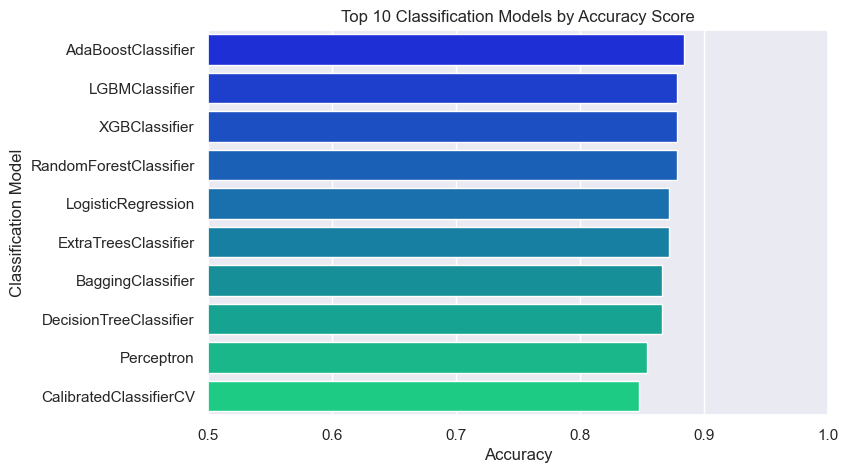

In [64]:
plt.figure(figsize=(8, 5))
sns.barplot(y=models_clf.index[:10], x=models_clf['Accuracy'][:10], palette='winter')
plt.xlabel("Accuracy")
plt.ylabel("Classification Model")
plt.title("Top 10 Classification Models by Accuracy Score")
plt.xlim(0.5, 1)
plt.show()